In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [70]:
df=pd.read_csv(r"C:\Users\rachi\Downloads\insurance_claims.csv")
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [71]:
df.shape

(1000, 40)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [73]:
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])
df['incident_date'] = pd.to_datetime(df['incident_date'])
df['policy_age_days'] = (df['incident_date'] - df['policy_bind_date']).dt.days

In [74]:
waste = df[['policy_number','_c39','incident_location','insured_zip','total_claim_amount','policy_bind_date','incident_date']]
df=df.drop(waste,axis=1)

In [75]:

df1 =pd.get_dummies(df,drop_first=True,dtype=int)

In [76]:
df1

,months_as_customer,age,policy_deductable,policy_annual_premium,umbrella_limit,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,...,auto_model_RAM,auto_model_RSX,auto_model_Silverado,auto_model_TL,auto_model_Tahoe,auto_model_Ultima,auto_model_Wrangler,auto_model_X5,auto_model_X6,fraud_reported_Y
0,328,48,1000,1406.91,0,53300,0,5,1,1,...,0,0,0,0,0,0,0,0,0,1
1,228,42,2000,1197.22,5000000,0,0,8,1,0,...,0,0,0,0,0,0,0,0,0,1
2,134,29,2000,1413.14,5000000,35100,0,7,3,2,...,1,0,0,0,0,0,0,0,0,0
3,256,41,2000,1415.74,6000000,48900,-62400,5,1,1,...,0,0,0,0,1,0,0,0,0,1
4,228,44,1000,1583.91,6000000,66000,-46000,20,1,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,1000,1310.80,0,0,0,20,1,0,...,0,0,0,0,0,0,0,0,0,0
996,285,41,1000,1436.79,0,70900,0,23,1,2,...,0,0,0,0,0,0,0,0,0,0
997,130,34,500,1383.49,3000000,35100,0,4,3,2,...,0,0,0,0,0,0,0,0,0,0
998,458,62,2000,1356.92,5000000,0,0,2,1,0,...,0,0,0,0,0,0,0,0,0,0


In [77]:
df1.dtypes

months_as_customer         int64
age                        int64
policy_deductable          int64
policy_annual_premium    float64
umbrella_limit             int64
                          ...   
auto_model_Ultima          int64
auto_model_Wrangler        int64
auto_model_X5              int64
auto_model_X6              int64
fraud_reported_Y           int64
Length: 144, dtype: object

<Axes: >

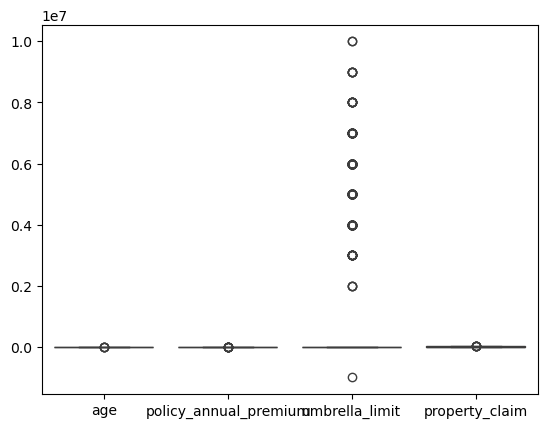

In [78]:
import seaborn as sns
sns.boxplot(df1[['age','policy_annual_premium','umbrella_limit','property_claim']])

In [79]:
df2=df1[['age','policy_annual_premium','umbrella_limit','property_claim']]
for i in df2:
    low = df1[i].quantile(0.25)
    up = df1[i].quantile(0.75)
    df1[i]=df1[i].clip(low,up)

In [80]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
df1[['policy_annual_premium','umbrella_limit','property_claim']] = ss.fit_transform(df1[['policy_annual_premium','umbrella_limit','property_claim']])

<Axes: >

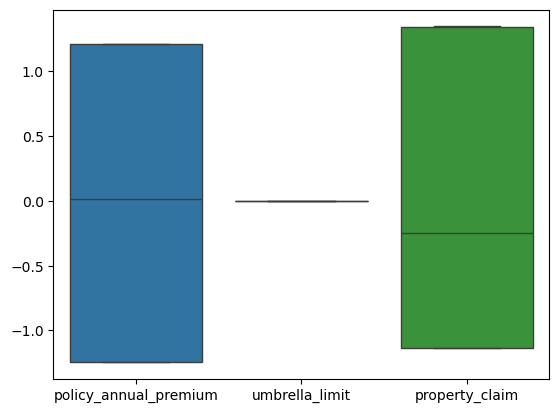

In [81]:
sns.boxplot(df1[['policy_annual_premium','umbrella_limit','property_claim']])

In [82]:
X=df.drop('fraud_reported',axis=1)


In [83]:
X=pd.get_dummies(X,drop_first=True,dtype=int)

In [84]:
y=df['fraud_reported']

In [85]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [86]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(criterion='entropy')
dtc.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [88]:
y_pred=dtc.predict(X_test)